# Task 4.1 — Building & Training a Variational Autoencoder (VAE) on MNIST

In this notebook, we:
1. **Implement a VAE** with an MLP encoder/decoder for 28×28 MNIST images.
2. **Encoder** outputs $\mu_\phi(x)$ and $\log \sigma^2_\phi(x)$ for a Gaussian latent variable $z$.
3. **Reparameterization trick**: $z = \mu_\phi(x) + \sigma_\phi(x) \odot \epsilon$, where $\epsilon \sim \mathcal{N}(0, I)$.
4. **Decoder** outputs Bernoulli pixel probabilities via sigmoid activation.
5. **ELBO loss** = Reconstruction (BCE) + KL Divergence: $\mathcal{L} = -\mathbb{E}_{q}[\log p_\theta(x|z)] + D_{\text{KL}}(q_\phi(z|x) \| \mathcal{N}(0,I))$.
6. **Train** for 20 epochs with Adam ($lr = 10^{-3}$), monitoring loss decomposition.
7. **Visualise** training curves showing how reconstruction fidelity and latent regularization balance over training.

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

from task4_vae.src.model import VAE
from task4_vae.src.train import train_vae, evaluate_vae

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


### Model Architecture Overview
Our VAE uses a simple MLP architecture designed for MNIST:

In [2]:
# Instantiate the VAE
LATENT_DIM = 2  # 2D for easy visualization
vae = VAE(input_dim=784, hidden_dim=400, latent_dim=LATENT_DIM)
print(vae)
print(f'\nTotal parameters: {sum(p.numel() for p in vae.parameters()):,}')
print(f'Latent dimension: {LATENT_DIM}')
print(f'\nArchitecture:')
print(f'  Encoder: 784 → 400 (ReLU) → {LATENT_DIM} (μ) + {LATENT_DIM} (logσ²)')
print(f'  Reparameterize: z = μ + σ ⊙ ε,  ε ~ N(0,I)')
print(f'  Decoder: {LATENT_DIM} → 400 (ReLU) → 784 (Sigmoid)')

VAE(
  (fc1): Linear(in_features=784, out_features=400, bias=True)
  (fc_mu): Linear(in_features=400, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=2, bias=True)
  (fc3): Linear(in_features=2, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=784, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

Total parameters: 631,188
Latent dimension: 2

Architecture:
  Encoder: 784 → 400 (ReLU) → 2 (μ) + 2 (logσ²)
  Reparameterize: z = μ + σ ⊙ ε,  ε ~ N(0,I)
  Decoder: 2 → 400 (ReLU) → 784 (Sigmoid)


### Load MNIST Dataset

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:04<00:00, 2.32MB/s]


Extracting ../data\MNIST\raw\train-images-idx3-ubyte.gz to ../data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 141kB/s]


Extracting ../data\MNIST\raw\train-labels-idx1-ubyte.gz to ../data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.18MB/s]


Extracting ../data\MNIST\raw\t10k-images-idx3-ubyte.gz to ../data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 4.45MB/s]


Extracting ../data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ../data\MNIST\raw

Training samples: 60000
Test samples:     10000
Batch size:       128


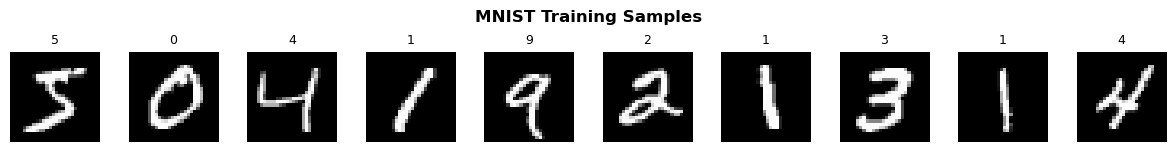

In [3]:
transform = transforms.ToTensor()  # Scales pixels to [0, 1] — matches Bernoulli assumption

train_dataset = torchvision.datasets.MNIST(root='../data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='../data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f'Training samples: {len(train_dataset)}')
print(f'Test samples:     {len(test_dataset)}')
print(f'Batch size:       128')

# Show a few sample images
fig, axes = plt.subplots(1, 10, figsize=(12, 1.5))
for i in range(10):
    axes[i].imshow(train_dataset[i][0].squeeze(), cmap='gray')
    axes[i].set_title(str(train_dataset[i][1]), fontsize=9)
    axes[i].axis('off')
fig.suptitle('MNIST Training Samples', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Train the VAE
Training for 20 epochs with Adam optimizer ($lr = 10^{-3}$). The ELBO loss decomposes as:

$$\mathcal{L} = \underbrace{-\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]}_{\text{BCE (reconstruction)}} + \underbrace{D_{\text{KL}}\big(q_\phi(z|x) \| p(z)\big)}_{\text{KL divergence}}$$

In [4]:
os.makedirs('../results/checkpoints', exist_ok=True)

history = train_vae(
    vae, train_loader, epochs=20, lr=1e-3, device=device,
    save_dir='../results/checkpoints'
)

print(f'\nFinal training loss: {history[-1]["loss"]:.2f}')

Epoch 1/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1/20 | Loss: 189.23 (BCE: 183.51, KLD: 5.73)


Epoch 2/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2/20 | Loss: 168.44 (BCE: 163.13, KLD: 5.31)


Epoch 3/20:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 18/20 | Loss: 151.75 (BCE: 145.85, KLD: 5.91)


Epoch 19/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 19/20 | Loss: 151.49 (BCE: 145.55, KLD: 5.94)


Epoch 20/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 20/20 | Loss: 151.16 (BCE: 145.22, KLD: 5.94)

Final training loss: 151.16


### Training Loss Curves
Monitoring the ELBO decomposition to ensure both reconstruction quality and latent regularization improve.

<>:26: SyntaxWarning: invalid escape sequence '\|'
<>:26: SyntaxWarning: invalid escape sequence '\|'
C:\Users\moize\AppData\Local\Temp\ipykernel_25172\2707653178.py:26: SyntaxWarning: invalid escape sequence '\|'
  axes[2].set_title('KL Divergence $D_{KL}(q \| p)$', fontsize=13, fontweight='bold')


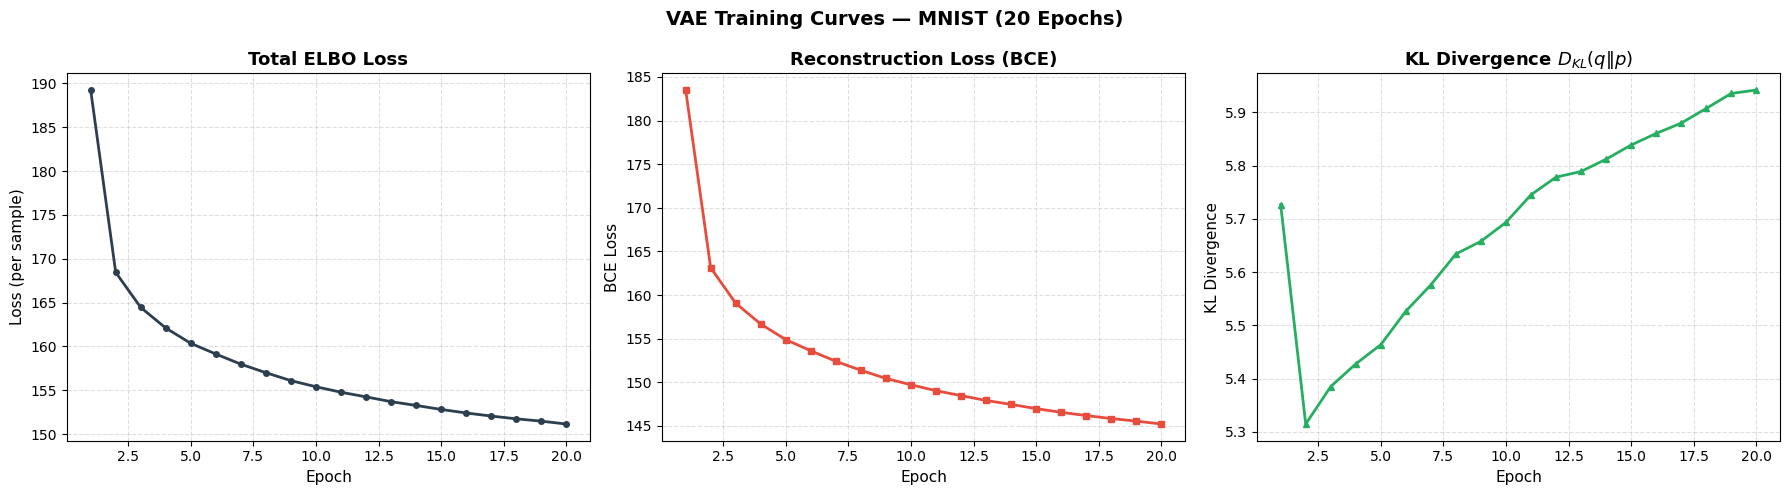

In [5]:
epochs_list = [h['epoch'] for h in history]
losses = [h['loss'] for h in history]
bces = [h['bce'] for h in history]
klds = [h['kld'] for h in history]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total ELBO Loss
axes[0].plot(epochs_list, losses, marker='o', color='#2c3e50', linewidth=2, markersize=4)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss (per sample)', fontsize=11)
axes[0].set_title('Total ELBO Loss', fontsize=13, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.4)

# Reconstruction Loss (BCE)
axes[1].plot(epochs_list, bces, marker='s', color='#e74c3c', linewidth=2, markersize=4)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('BCE Loss', fontsize=11)
axes[1].set_title('Reconstruction Loss (BCE)', fontsize=13, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.4)

# KL Divergence
axes[2].plot(epochs_list, klds, marker='^', color='#27ae60', linewidth=2, markersize=4)
axes[2].set_xlabel('Epoch', fontsize=11)
axes[2].set_ylabel('KL Divergence', fontsize=11)
axes[2].set_title('KL Divergence $D_{KL}(q \| p)$', fontsize=13, fontweight='bold')
axes[2].grid(True, linestyle='--', alpha=0.4)

fig.suptitle('VAE Training Curves — MNIST (20 Epochs)', fontsize=14, fontweight='bold')
plt.tight_layout()
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/vae_training_curves.png', bbox_inches='tight', dpi=300)
plt.show()

### Combined Loss Overlay

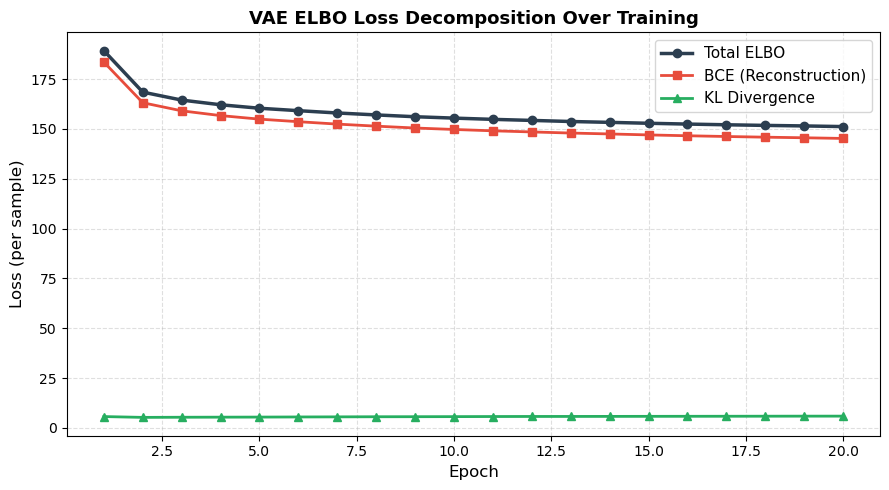

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epochs_list, losses, marker='o', label='Total ELBO', color='#2c3e50', linewidth=2.5)
ax.plot(epochs_list, bces, marker='s', label='BCE (Reconstruction)', color='#e74c3c', linewidth=2)
ax.plot(epochs_list, klds, marker='^', label='KL Divergence', color='#27ae60', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (per sample)', fontsize=12)
ax.set_title('VAE ELBO Loss Decomposition Over Training', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../results/figures/vae_loss_overlay.png', bbox_inches='tight', dpi=300)
plt.show()

### Test Set Evaluation

In [7]:
test_metrics = evaluate_vae(vae, test_loader, device=device)
print(f'Test Set Evaluation:')
print(f'  Total Loss:     {test_metrics["loss"]:.2f}')
print(f'  Reconstruction: {test_metrics["bce"]:.2f}')
print(f'  KL Divergence:  {test_metrics["kld"]:.2f}')

Test Set Evaluation:
  Total Loss:     153.10
  Reconstruction: 147.06
  KL Divergence:  6.04
